start internship 3 week task

 import libraries


In [18]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For saving the model
import joblib

# Style settings for better plots
sns.set_style("whitegrid")
%matplotlib inline

load the dataset

In [19]:

df = pd.read_csv("steel_industry_feature_engineered.csv")

df.shape


(35040, 16)

In [20]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,daytype,Power_factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,weekday,1.545117,0


drope the leakage columns

In [21]:
df.drop(columns=["date", "High_Load"], inplace=True)


fillmising value in columns power factor ratio becouse one missing value in data

In [22]:
df["Power_factor_Ratio"] = df["Power_factor_Ratio"].fillna(df["Power_factor_Ratio"].mean())


 One-Hot Encoding for categorical columns (same as Week 2)


In [23]:
categorical_cols = ["WeekStatus", "Day_of_week", "Load_Type", "daytype", "Month"]


In [24]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


In [25]:
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_factor_Ratio,WeekStatus_Weekend,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,0,...,0,0,1,0,0,0,0,0,0,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,0,...,0,0,1,0,0,0,0,0,0,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,0,...,0,0,1,0,0,0,0,0,0,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,0,...,0,0,1,0,0,0,0,0,0,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,0,...,0,0,1,0,0,0,0,0,0,0


In [26]:
df.shape

(35040, 30)

 Separate features (X) and target (y)


In [27]:
X = df.drop("Usage_kWh", axis=1)
y = df["Usage_kWh"]


 Use the EXACT same split as Week 2 (random_state=42)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Standardization (Scale the Data)


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Initialize PCA keeping ALL components


In [30]:
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
X_test_pca_full = pca_full.transform(X_test_scaled)


 Explained variance ratio for each component


In [31]:
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)


In [32]:
len(explained_variance)

29

In [33]:
print(f"First 5 components explain: {cumulative_variance[4]:.2%}")


First 5 components explain: 44.58%


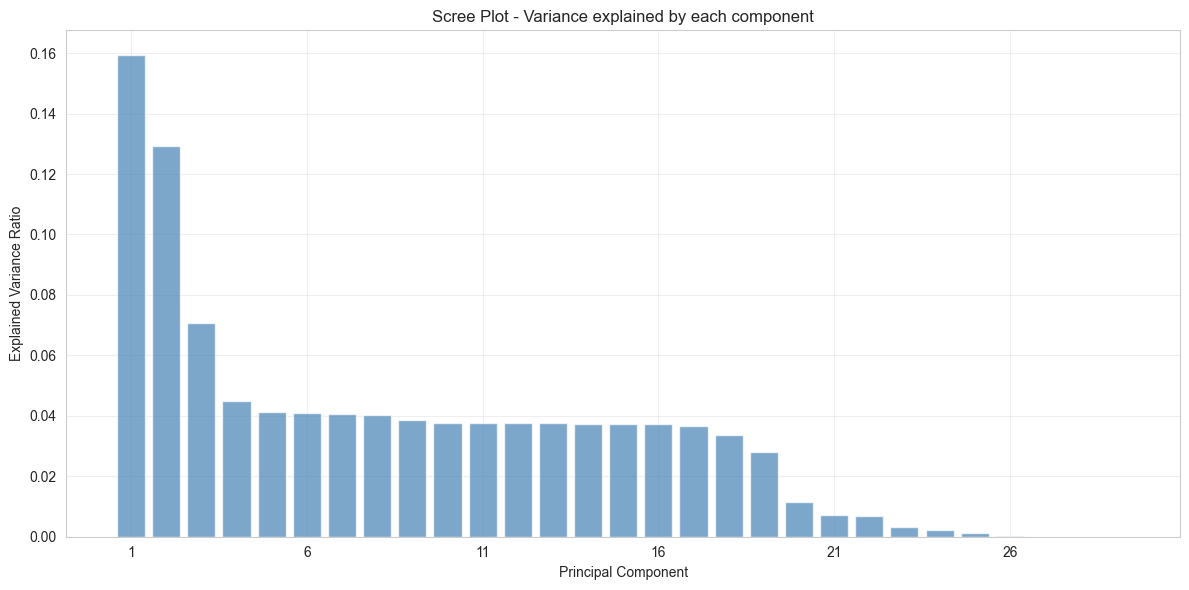

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Variance explained by each component')
plt.xticks(range(1, len(explained_variance)+1, 5))  # Show every 5th label
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scree_plot.png')  # Save for FastAPI
plt.show()

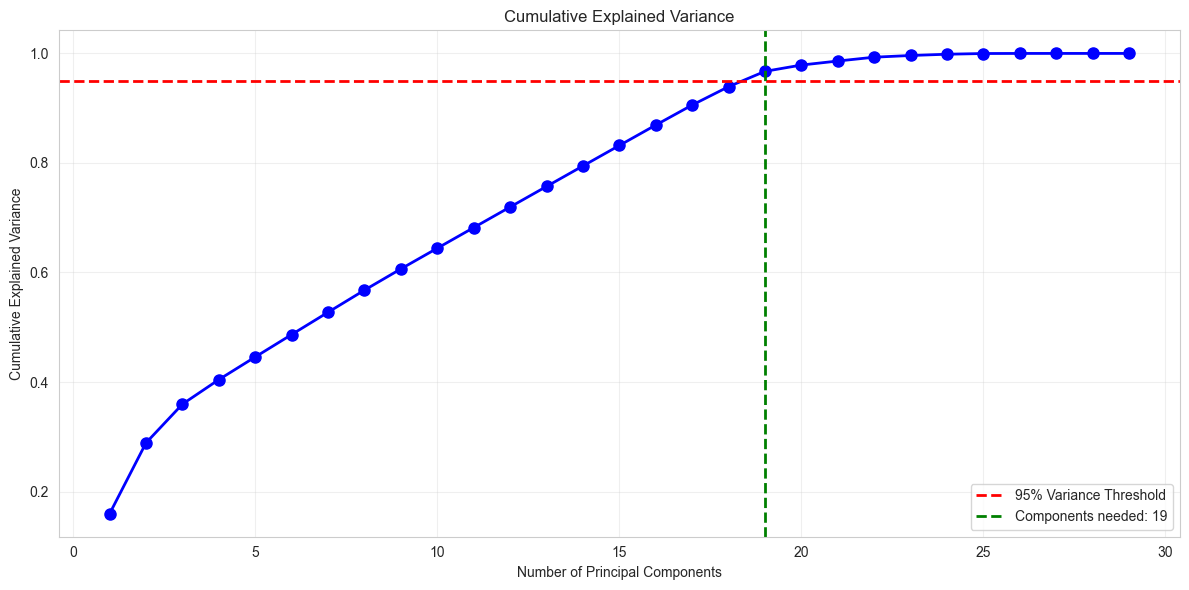

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold', linewidth=2)

# Find how many components reach 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'Components needed: {n_components_95}', linewidth=2)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_variance.png')
plt.show()



In [38]:
print(f"We need {n_components_95} components to capture 95% of the variance.")

We need 19 components to capture 95% of the variance.


 Apply PCA with 3 components


In [39]:
pca_3 = PCA(n_components=3)


In [40]:
X_train_pca_3 = pca_3.fit_transform(X_train_scaled)
X_test_pca_3 = pca_3.transform(X_test_scaled)


 Train Random Forest


In [41]:
rf_3 = RandomForestRegressor(n_estimators=100, random_state=42)


In [42]:
rf_3.fit(X_train_pca_3, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Predict & Evaluate


In [43]:
y_pred_3 = rf_3.predict(X_test_pca_3)


In [44]:
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))


In [45]:
r2_3 = r2_score(y_test, y_pred_3)


In [46]:
print(f"3-Component Model -> RMSE: {rmse_3:.4f}, R²: {r2_3:.4f}")


3-Component Model -> RMSE: 6.3083, R²: 0.9650


 Apply PCA with 95% components


In [47]:
pca_95 = PCA(n_components=n_components_95)


In [48]:
X_train_pca_95 = pca_95.fit_transform(X_train_scaled)


In [49]:
X_test_pca_95 = pca_95.transform(X_test_scaled)


 Train Random Forest


In [50]:
rf_95 = RandomForestRegressor(n_estimators=100, random_state=42)


In [51]:
rf_95.fit(X_train_pca_95, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Predict & Evaluate


In [52]:
y_pred_95 = rf_95.predict(X_test_pca_95)


In [53]:
rmse_95 = np.sqrt(mean_squared_error(y_test, y_pred_95))


In [54]:
r2_95 = r2_score(y_test, y_pred_95)


In [55]:
print(f"95%-Component Model -> RMSE: {rmse_95:.4f}, R²: {r2_95:.4f}")


95%-Component Model -> RMSE: 3.4475, R²: 0.9895


Original Random Forest on ALL scaled features


In [56]:
rf_orig = RandomForestRegressor(n_estimators=100, random_state=42)


In [57]:
rf_orig.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [58]:
y_pred_orig = rf_orig.predict(X_test_scaled)


In [59]:
rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))


In [60]:
r2_orig = r2_score(y_test, y_pred_orig)


In [61]:
print(f"Original Model -> RMSE: {rmse_orig:.4f}, R²: {r2_orig:.4f}")


Original Model -> RMSE: 1.0363, R²: 0.9991


final comparsion

In [62]:
comparison_df = pd.DataFrame({
    "Model": ["Original (All Features)", "3 PCA Components", f"{n_components_95} PCA Components (95% var)"],
    "RMSE": [rmse_orig, rmse_3, rmse_95],
    "R²": [r2_orig, r2_3, r2_95],
    "Features Used": [X_train.shape[1], 3, n_components_95]
})

print(comparison_df.to_string(index=False))

                      Model     RMSE       R²  Features Used
    Original (All Features) 1.036274 0.999055             29
           3 PCA Components 6.308330 0.964991              3
19 PCA Components (95% var) 3.447483 0.989544             19


 Loadings matrix: components x features (transpose to get features x components)


In [63]:
loadings = pca_3.components_.T  # Shape: (n_features, 3)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\farhan ali\\Desktop\\week3_task\\notebbook\\static\\loading_heatmap.png'

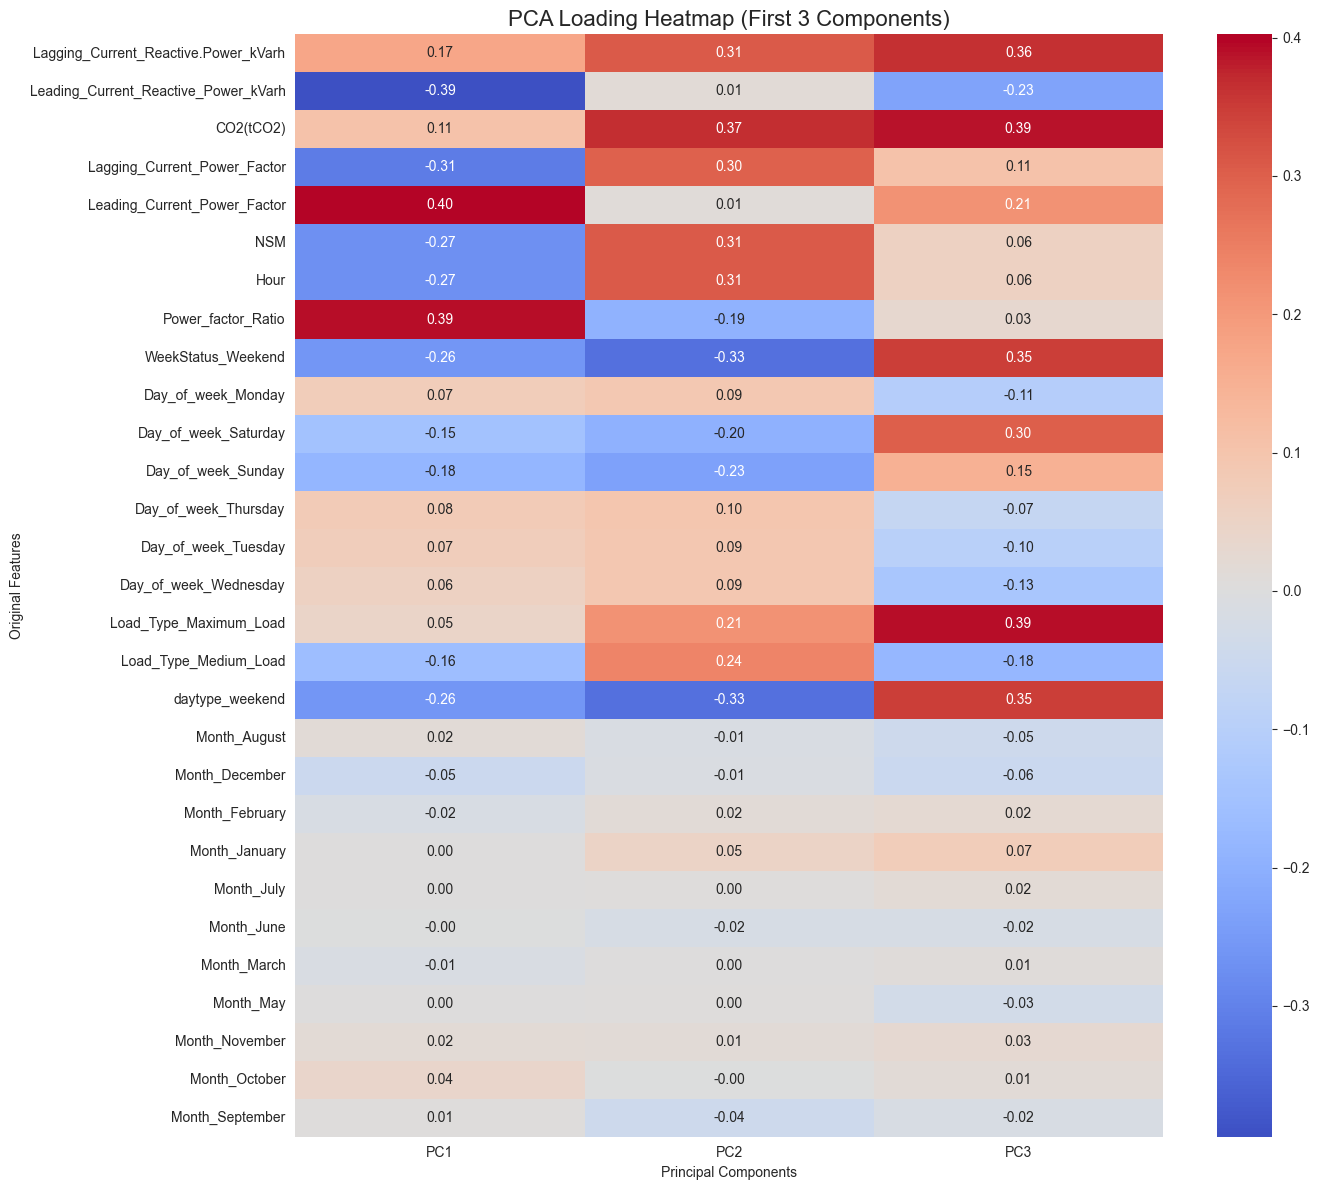

In [64]:
plt.figure(figsize=(14, 12))
sns.heatmap(loadings, 
            cmap='coolwarm', 
            center=0,
            annot=True,          # Show numbers inside boxes
            fmt='.2f',
            xticklabels=['PC1', 'PC2', 'PC3'],
            yticklabels=X.columns)
plt.title('PCA Loading Heatmap (First 3 Components)', fontsize=16)
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.savefig('static/loading_heatmap.png')
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', scaler),
    ('model', rf_orig)
])
joblib.dump(pipeline, 'model.joblib')
print("Pipeline saved as 'model.joblib'")

✅ Pipeline saved as 'model.joblib'


In [ ]:
df.head()

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [67]:
# Ensure static folder exists
os.makedirs('static', exist_ok=True)
print("✅ Static folder is ready")

✅ Static folder is ready


In [72]:
df.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'Hour', 'Power_factor_Ratio', 'WeekStatus_Weekend',
       'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday',
       'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday',
       'Load_Type_Maximum_Load', 'Load_Type_Medium_Load', 'daytype_weekend',
       'Month_August', 'Month_December', 'Month_February', 'Month_January',
       'Month_July', 'Month_June', 'Month_March', 'Month_May',
       'Month_November', 'Month_October', 'Month_September'],
      dtype='object')

In [73]:
plt.figure(figsize=(12, 6))
hourly_energy = df.groupby('Hour')['Usage_kWh'].mean()
sns.barplot(x=hourly_energy.index, y=hourly_energy.values, palette='viridis')
plt.title('Average Energy Consumption by Hour', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('static/energy_by_hour.png')
plt.close()

C:\Windows\Temp\ipykernel_9224\1814775856.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_energy.index, y=hourly_energy.values, palette='viridis')


In [76]:
plt.figure(figsize=(10, 6))
load_energy = df.groupby('Load_Type_Medium_Load')['Usage_kWh'].mean().sort_values()
sns.barplot(x=load_energy.values, y=load_energy.index, palette='magma')
plt.title('Average Energy Consumption by Load Type', fontsize=14)
plt.xlabel('Average Usage (kWh)')
plt.ylabel('Load Type')
plt.tight_layout()
plt.savefig('static/energy_by_load.png')
plt.close()
print("✅ Saved: static/energy_by_load.png")

C:\Windows\Temp\ipykernel_9224\3980215995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=load_energy.values, y=load_energy.index, palette='magma')


✅ Saved: static/energy_by_load.png


In [77]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()

sns.heatmap(corr, 
            cmap='coolwarm', 
            center=0,
            annot=False,   
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('static/correlation_heatmap.png')
plt.close()
print("✅ Saved: static/correlation_heatmap.png")

✅ Saved: static/correlation_heatmap.png
